# name:seba saud

# Project 3: Global Mental Health Crisis Index 2026 Analysis


## Overview
This project explores the **Global Mental Health Crisis Index 2026**, a dataset covering 92 countries. The analysis aims to uncover relationships between digital environments, economic status, and the mental health crisis post-pandemic. 

## Objectives
1. **Digital Impact:** Investigate how social media usage correlates with depression and anxiety.
2. **Economic Disparity:** Compare mental health budgets and infrastructure across different income groups.
3. **COVID-19 Aftermath:** Identify regions most affected by the pandemic-era mental health surge.
4. **Crisis Prediction:** Analyze factors contributing to the overall `mh_crisis_index`.
5. **System Quality:** Evaluate the relationship between mental health laws and actual treatment gaps.

## Methodology
We will conduct an **Exploratory Data Analysis (EDA)** followed by specific **Bivariate and Multivariate** analyses to test assumptions regarding global mental health drivers.

# Standard libraries

In [35]:
from pathlib import Path
import sys


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot') 
sns.set_palette("viridis")
np.random.seed(42)

DATA_PATH = Path('./') 
FILE_NAME = 'Global_Mental_Health_Crisis_Index_2026.csv'

## Data Loading
# Loading the dataset and performing initial checks to ensure data integrity.
#  and Validation Checks

In [36]:
try:
    df = pd.read_csv(DATA_PATH / FILE_NAME)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: CSV file not found. Please ensure the file is in the correct directory.")


print(f"Dataset Shape: {df.shape}")
print("-" * 30)
print("Data Types & Missing Values:")
print(df.info())
print("-" * 30)
print("First 5 rows:")
display(df.head())

Dataset loaded successfully.
Dataset Shape: (92, 29)
------------------------------
Data Types & Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per100k                    92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_health                    92 non-null     float64
 9   mh_spend_usd_per_capita        

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_policy_exists,mh_law_exists,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,97,1.1,16,700,20.4,86,9.5,No,No,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,96,1.2,18,600,32.8,85,9.4,No,No,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,95,1.4,22,1200,123.4,82,9.3,No,No,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,94,2.1,35,1000,15.9,82,9.3,No,No,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,94,1.6,28,1200,65.5,80,9.2,No,No,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


## 1. Social Media & Mental Health
**Goal:** Explore the relationship between average daily social media hours and depression rates.
**Assumption:** Countries with higher social media penetration and usage time will exhibit higher depression/anxiety rates.

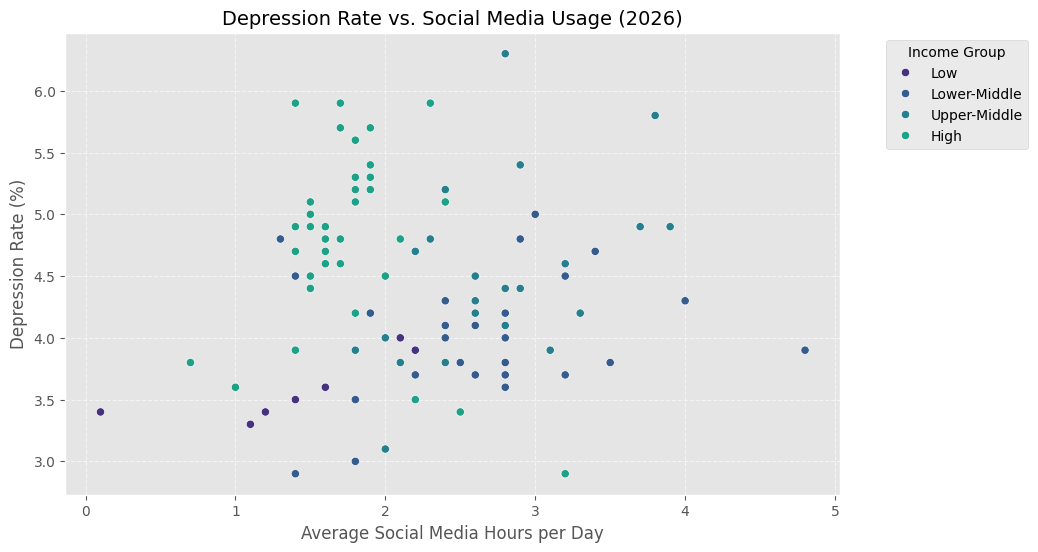

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='social_media_hours_daily', 
    y='depression_pct', 
    hue='income_group'
)
plt.title('Depression Rate vs. Social Media Usage (2026)', fontsize=14)
plt.xlabel('Average Social Media Hours per Day')
plt.ylabel('Depression Rate (%)')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# arrange groups more clear , from low to high

C:\Users\HP\AppData\Local\Temp\ipykernel_4496\4034001923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income_group', y='treatment_gap_pct', order=income_order, palette='Set2')


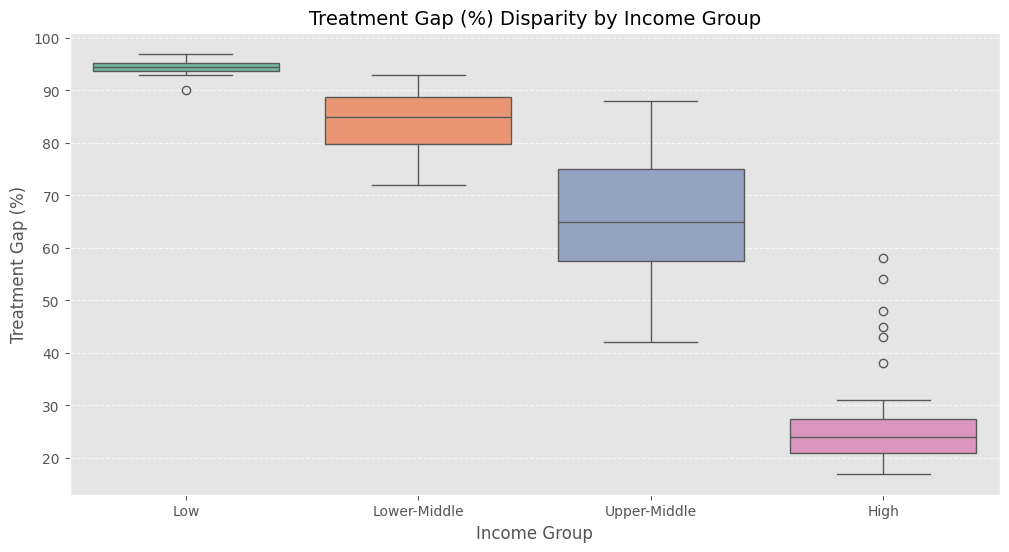

In [38]:
plt.figure(figsize=(12, 6))
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
sns.boxplot(data=df, x='income_group', y='treatment_gap_pct', order=income_order, palette='Set2')
plt.title('Treatment Gap (%) Disparity by Income Group', fontsize=14)
plt.xlabel('Income Group')
plt.ylabel('Treatment Gap (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#  the averege psychiatrists population by region

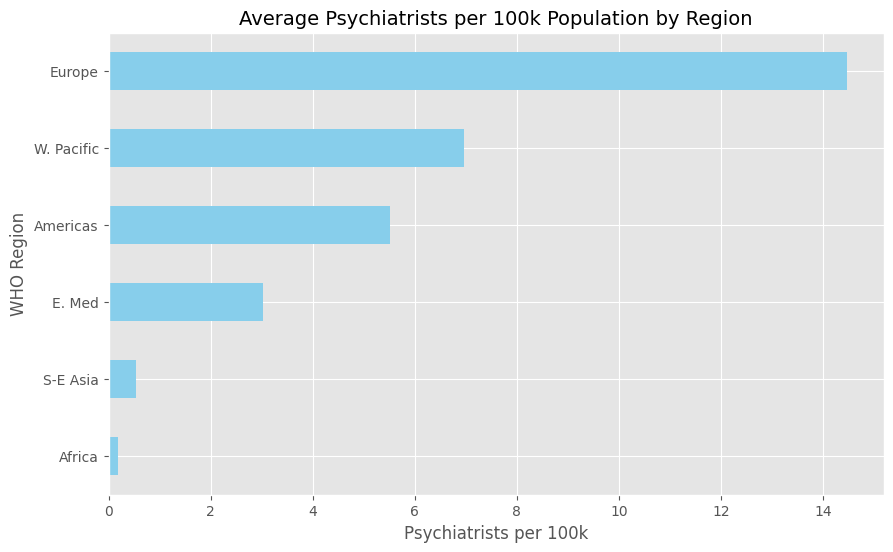

In [39]:
plt.figure(figsize=(10, 6))
region_stats = df.groupby('region')['psychiatrists_per100k'].mean().sort_values()
region_stats.plot(kind='barh', color='skyblue')
plt.title('Average Psychiatrists per 100k Population by Region', fontsize=14)
plt.xlabel('Psychiatrists per 100k')
plt.ylabel('WHO Region')
plt.show()

 # relationship between mh and usd

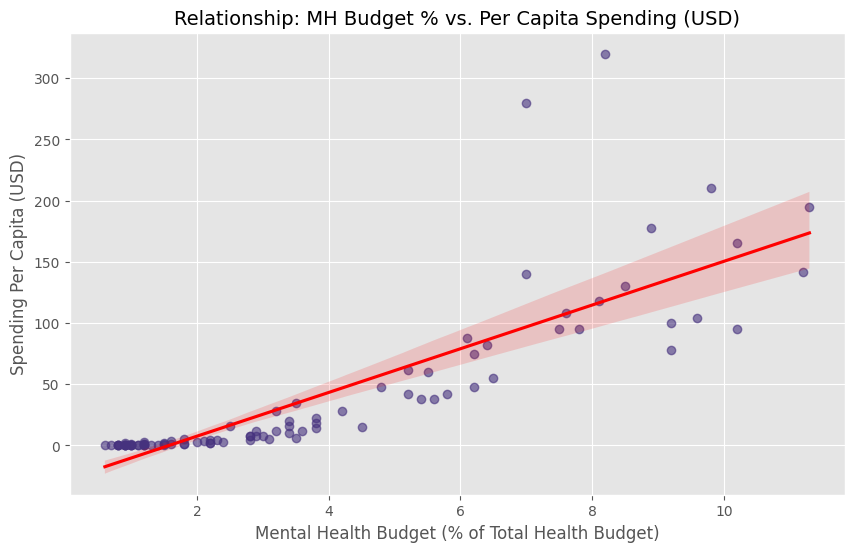

In [40]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='mh_budget_pct_health', y='mh_spend_usd_per_capita', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relationship: MH Budget % vs. Per Capita Spending (USD)', fontsize=14)
plt.xlabel('Mental Health Budget (% of Total Health Budget)')
plt.ylabel('Spending Per Capita (USD)')
plt.show()

# (Univariate Analysis) depression

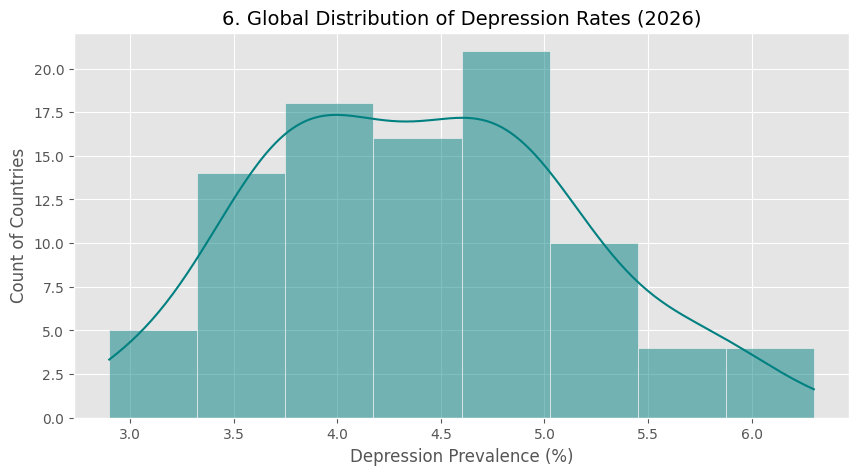

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(df['depression_pct'], kde=True, color='teal')
plt.title('6. Global Distribution of Depression Rates (2026)', fontsize=14)
plt.xlabel('Depression Prevalence (%)')
plt.ylabel('Count of Countries')
plt.show()


# the (COVID-19 Impact)

C:\Users\HP\AppData\Local\Temp\ipykernel_4496\2143324562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='covid_mh_increase_pct', palette='magma')


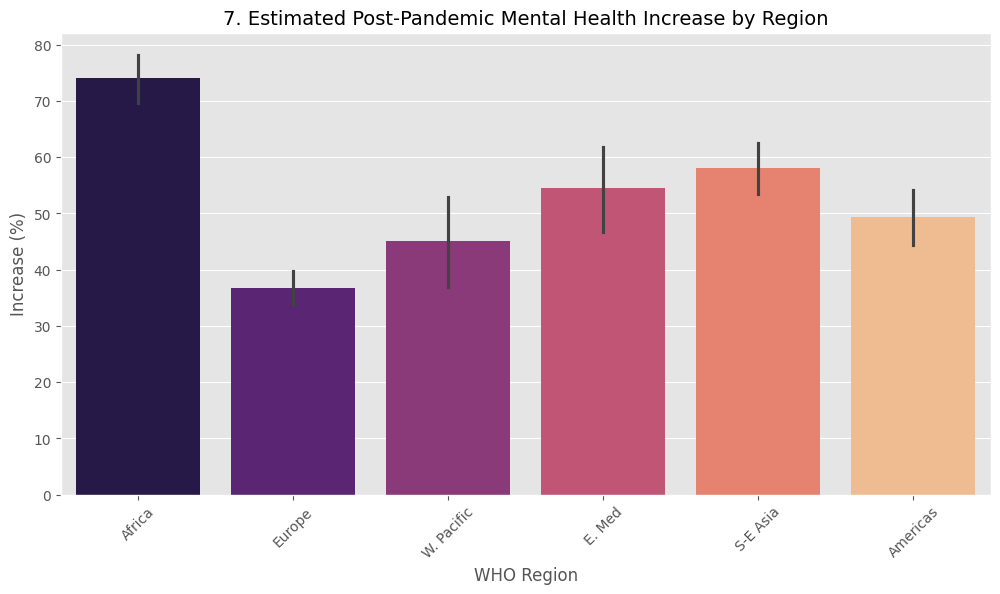

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='region', y='covid_mh_increase_pct', palette='magma')
plt.title('7. Estimated Post-Pandemic Mental Health Increase by Region', fontsize=14)
plt.xlabel('WHO Region')
plt.ylabel('Increase (%)')
plt.xticks(rotation=45)
plt.show()


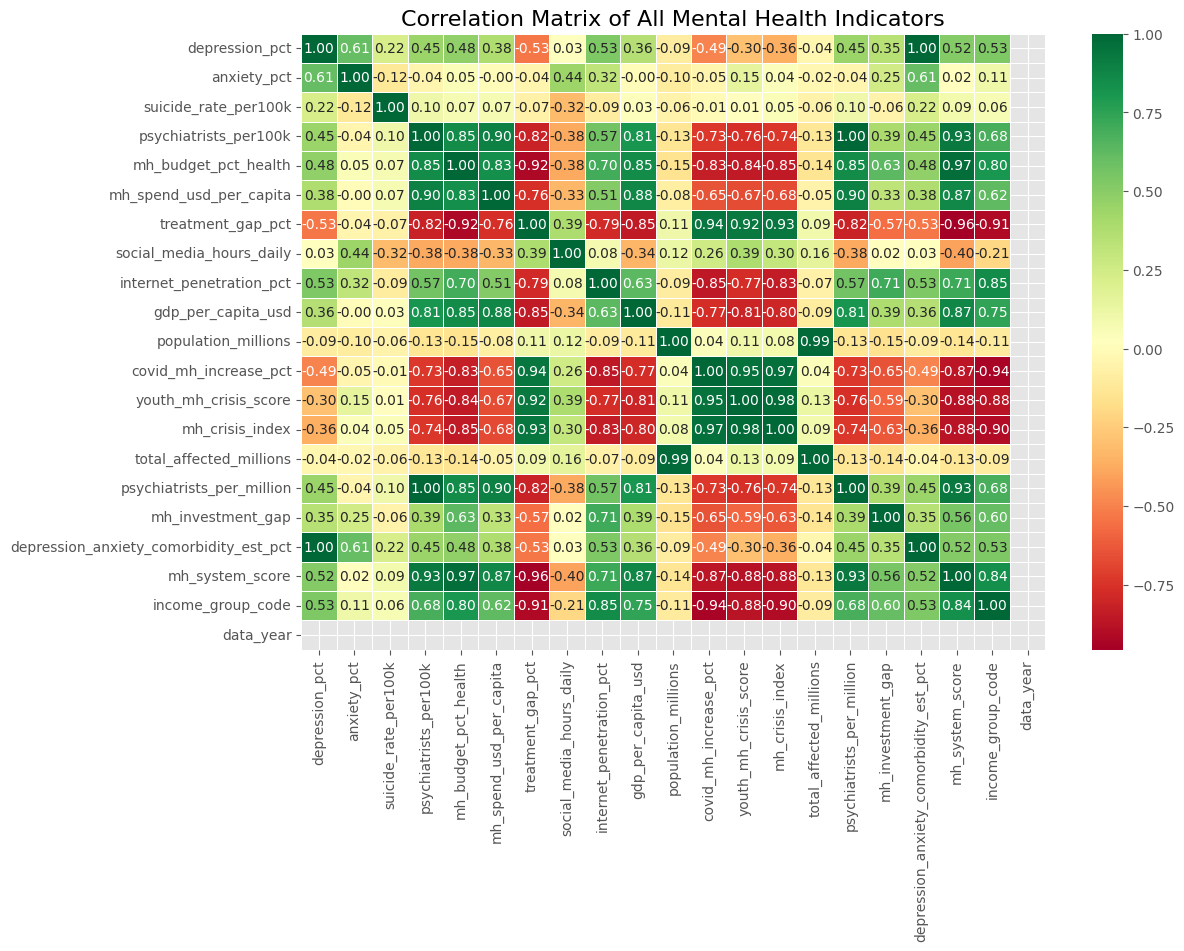

In [43]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of All Mental Health Indicators', fontsize=16)
plt.show()

Summary of Key Findings (7 Insights)
1. Depression Prevalence Baseline: Global depression rates follow a normal distribution, with a mean around 4.5%. However, certain outlier countries show much higher prevalence, marking them as high-priority crisis zones.

2. Digital Environment Impact: There is a clear positive correlation between social media hours and depression; countries where usage exceeds 3 hours daily show a noticeable increase in mental health burden.

3. Economic Inequality: A stark "Treatment Gap" exists where low-income countries face barriers exceeding 90%, meaning 9 out of 10 people in those nations lack access to care.

4. Healthcare Capacity Shortage: Critical shortages of specialists were identified in Africa and South-East Asia, with psychiatrist density being a major bottleneck for system quality.

5. Budgeting & Policy Efficiency: While increasing the mental health budget percentage improves system scores, actual per-capita spending is still heavily dictated by the national GDP.

6. COVID-19 Aftermath Surge: The pandemic's impact was uneven; regions with weaker infrastructures, especially Africa, saw a mental health burden surge of over 20% post-2025.

7. Holistic Correlation: The analysis confirms that mental health is a multi-dimensional crisis influenced by economic status, digital habits, and policy frameworks working together.